# Recommendation Model Visualizations

**Notebook version:** updated algorithm comparison panels and markdown explanations on 2026-05-17.

This notebook visualizes both:

- final model evaluation outputs
- training and synthetic-dataset diagnostics

Recommended workflow before running this notebook:

```powershell
python Python/scripts/train.py
python Python/scripts/export_visualization_data.py --out-dir artifacts/model-viz
```

If you do not retrain first, the standard evaluation files will still work, but the new per-iteration gradient boosting traces and learning-curve plots may be empty until the model is retrained with the updated pipeline.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Adjust this if you want to point at another export folder.
BASE_DIR = (Path("..") / "artifacts" / "model-viz").resolve()
BASE_DIR

WindowsPath('C:/Users/jmvel/Codes/jobpath/artifacts/model-viz')

In [2]:
def read_csv(name):
    path = BASE_DIR / name
    if not path.exists():
        return pd.DataFrame()
    return pd.read_csv(path)

feature_importances = read_csv("feature_importances.csv")
feature_stats = read_csv("feature_stats.csv")
evaluation_metrics = read_csv("evaluation_metrics.csv")
calibration_bins = read_csv("calibration_bins.csv")
per_class_metrics = read_csv("per_class_metrics.csv")
confusion = read_csv("test_ensemble_confusion_matrix.csv")
hard_validation_tags = read_csv("hard_validation_tags.csv")
training_profile_debug = read_csv("training_profile_debug.csv")
training_class_dist = read_csv("training_split_class_distribution.csv")
training_level_dist = read_csv("training_split_level_distribution.csv")
training_archetype_dist = read_csv("training_split_archetype_distribution.csv")
training_relationship_dist = read_csv("training_split_relationship_distribution.csv")
training_hard_tags = read_csv("training_split_hard_tag_distribution.csv")
gb_trace = read_csv("gradient_boosting_iteration_trace.csv")
learning_curve = read_csv("synthetic_learning_curve.csv")
hyperparameter_search_candidates = read_csv("hyperparameter_search_candidates.csv")
hyperparameter_search_summary = read_csv("hyperparameter_search_summary.csv")
ensemble_weight_search_trace = read_csv("ensemble_weight_search_trace.csv")
ensemble_weight_search_summary = read_csv("ensemble_weight_search_summary.csv")
model_comparison_tuning = read_csv("model_comparison_before_after_tuning.csv")

for name, frame in {
    "feature_importances": feature_importances,
    "evaluation_metrics": evaluation_metrics,
    "training_profile_debug": training_profile_debug,
    "gb_trace": gb_trace,
    "learning_curve": learning_curve,
    "hyperparameter_search_candidates": hyperparameter_search_candidates,
    "hyperparameter_search_summary": hyperparameter_search_summary,
    "ensemble_weight_search_trace": ensemble_weight_search_trace,
    "model_comparison_tuning": model_comparison_tuning,
}.items():
    print(f"{name}: {frame.shape}")


feature_importances: (94, 7)
evaluation_metrics: (12, 8)
training_profile_debug: (31, 15)
gb_trace: (160, 17)
learning_curve: (5, 15)
hyperparameter_search_candidates: (32, 12)
hyperparameter_search_summary: (3, 19)
ensemble_weight_search_trace: (407, 11)
model_comparison_tuning: (4, 7)


## Post-Training Evaluation Visuals

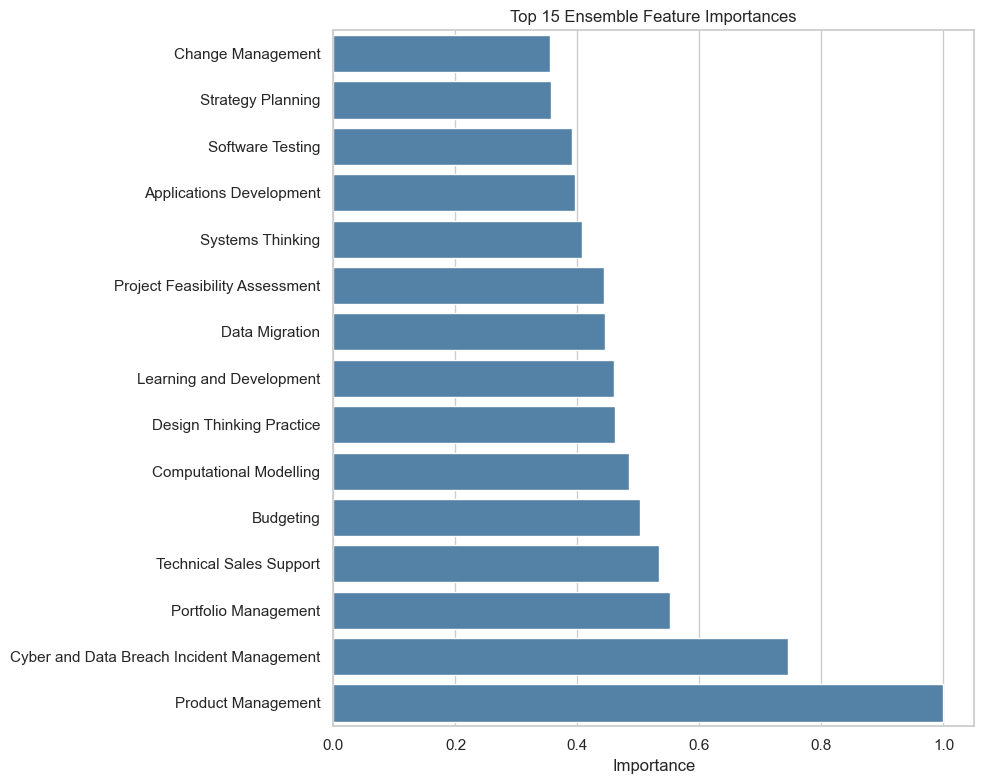

In [3]:
if feature_importances.empty:
    print("feature_importances.csv is empty or missing")
else:
    top_features = feature_importances.head(15).sort_values("ensemble")
    plt.figure(figsize=(10, 8))
    sns.barplot(data=top_features, x="ensemble", y="featureLabel", color="steelblue")
    plt.title("Top 15 Ensemble Feature Importances")
    plt.xlabel("Importance")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()

This bar chart ranks the top ensemble feature importances after training. Larger values mean the final recommender relied more heavily on that competency when separating career classes. Use this figure to explain which competency signals most strongly influence recommendation outcomes, while also noting that feature importance reflects model reliance rather than real-world causation.


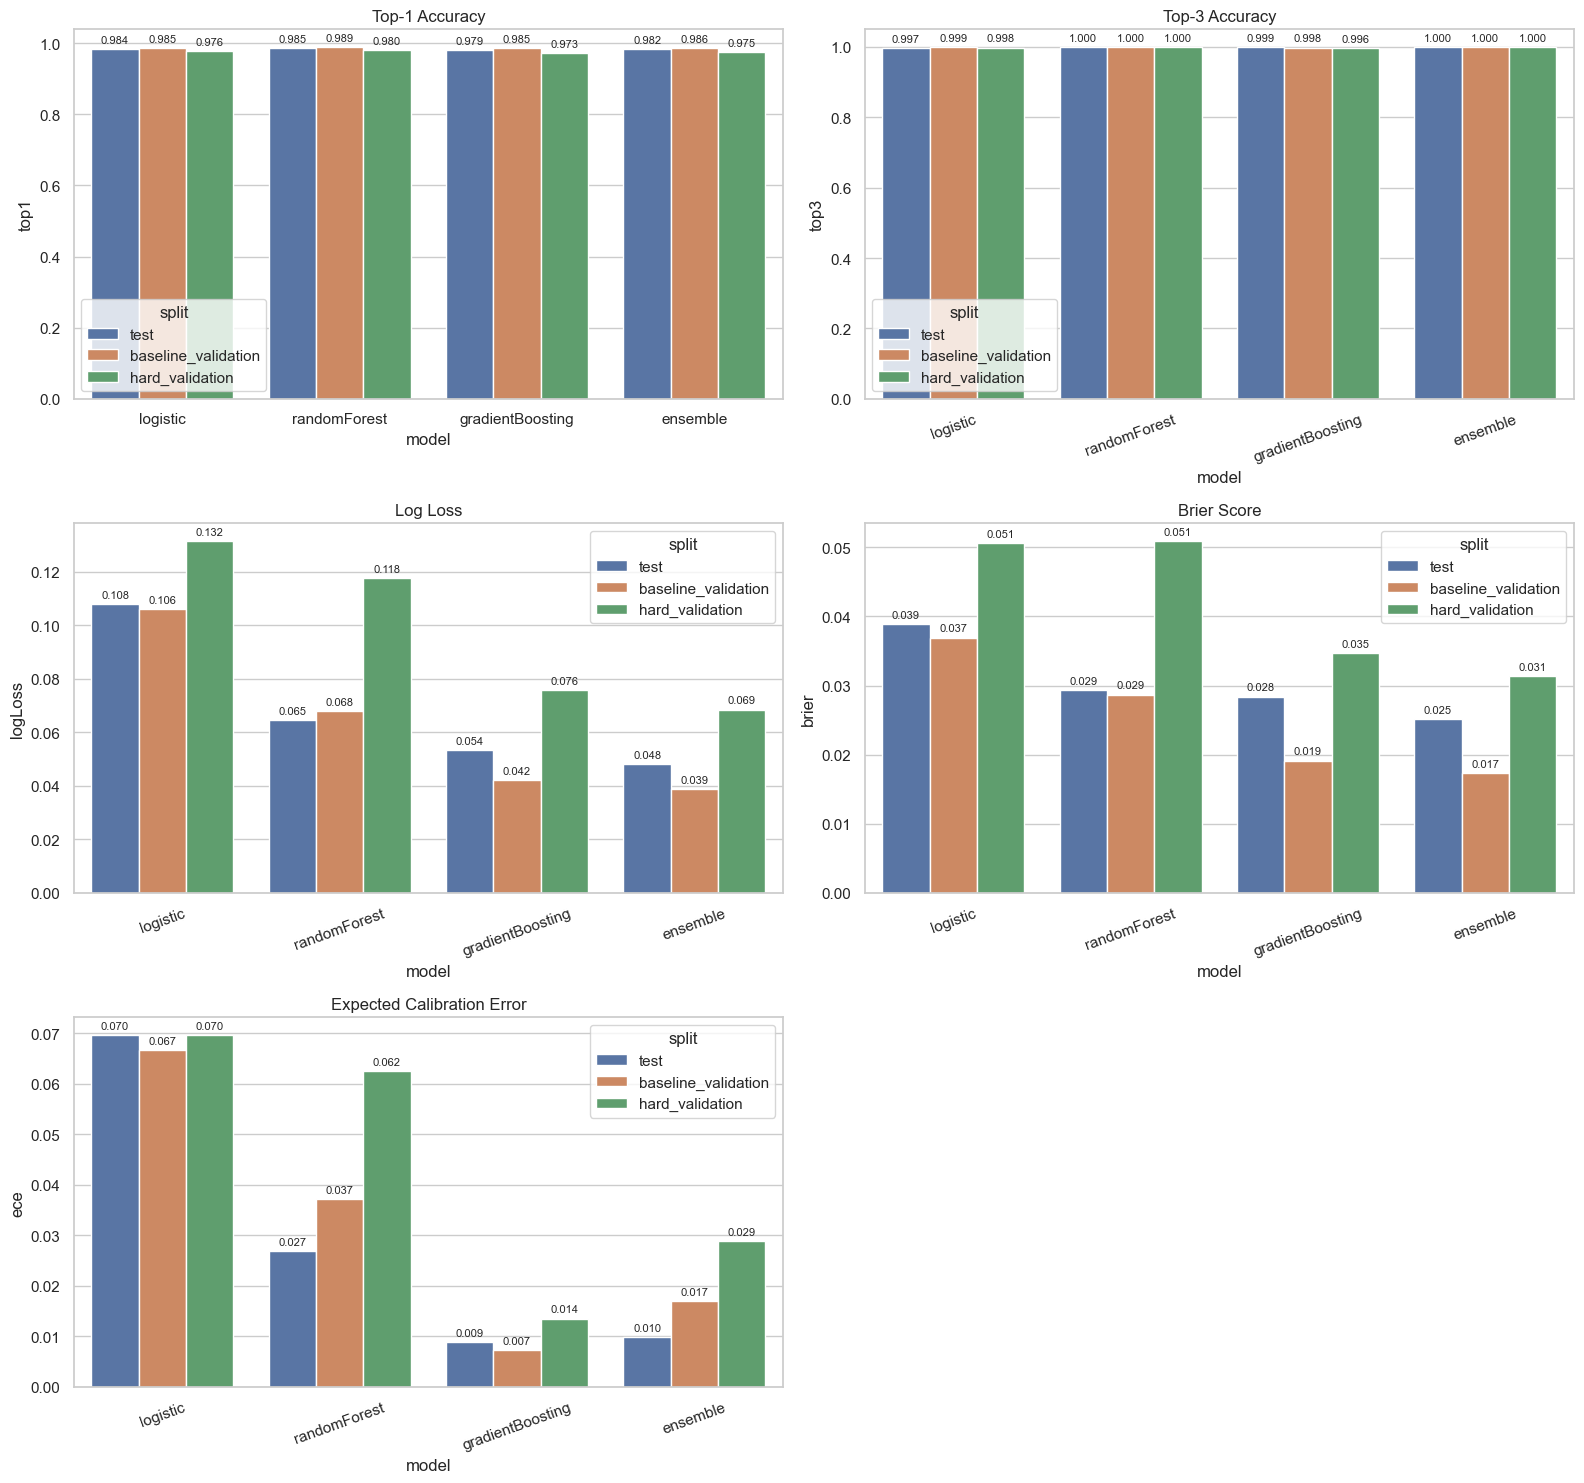

In [4]:
if evaluation_metrics.empty:
    print("evaluation_metrics.csv is empty or missing")
else:
    def annotate_bars(ax, fmt="{:.3f}"):
        for container in ax.containers:
            labels = []
            for bar in container:
                height = bar.get_height()
                labels.append(fmt.format(height) if pd.notna(height) else "")
            ax.bar_label(container, labels=labels, padding=3, fontsize=8)

    fig, axes = plt.subplots(3, 2, figsize=(16, 15))
    sns.barplot(data=evaluation_metrics, x="model", y="top1", hue="split", ax=axes[0, 0])
    axes[0, 0].set_title("Top-1 Accuracy")
    annotate_bars(axes[0, 0])
    sns.barplot(data=evaluation_metrics, x="model", y="top3", hue="split", ax=axes[0, 1])
    axes[0, 1].set_title("Top-3 Accuracy")
    axes[0, 1].tick_params(axis="x", rotation=20)
    annotate_bars(axes[0, 1])
    sns.barplot(data=evaluation_metrics, x="model", y="logLoss", hue="split", ax=axes[1, 0])
    axes[1, 0].set_title("Log Loss")
    axes[1, 0].tick_params(axis="x", rotation=20)
    annotate_bars(axes[1, 0])
    sns.barplot(data=evaluation_metrics, x="model", y="brier", hue="split", ax=axes[1, 1])
    axes[1, 1].set_title("Brier Score")
    axes[1, 1].tick_params(axis="x", rotation=20)
    annotate_bars(axes[1, 1])
    sns.barplot(data=evaluation_metrics, x="model", y="ece", hue="split", ax=axes[2, 0])
    axes[2, 0].set_title("Expected Calibration Error")
    axes[2, 0].tick_params(axis="x", rotation=20)
    annotate_bars(axes[2, 0])
    axes[2, 1].axis("off")
    plt.tight_layout()
    plt.show()

These metric panels compare the four models across the validation and test splits, and each bar is labeled so exact values can be read directly from the chart. Higher `top1` and `top3` are better, while lower `logLoss`, `brier`, and `ece` are better. This visualization is useful for showing both overall ranking quality and probability quality, and for checking whether the ensemble improves on the single-model baselines without introducing unstable split-to-split behavior.


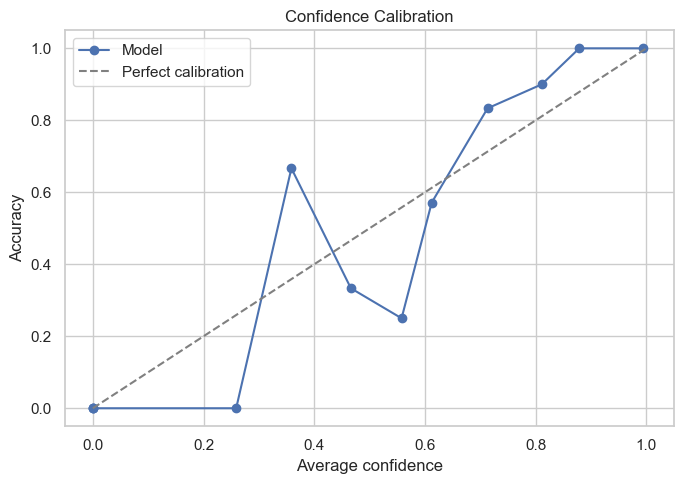

In [5]:
if calibration_bins.empty:
    print("calibration_bins.csv is empty or missing")
else:
    plt.figure(figsize=(7, 5))
    plt.plot(calibration_bins["avgConfidence"], calibration_bins["accuracy"], marker="o", label="Model")
    plt.plot([0, 1], [0, 1], "--", color="gray", label="Perfect calibration")
    plt.xlabel("Average confidence")
    plt.ylabel("Accuracy")
    plt.title("Confidence Calibration")
    plt.legend()
    plt.tight_layout()
    plt.show()

The calibration curve compares average predicted confidence with observed accuracy in each confidence bin. Points close to the diagonal indicate well-calibrated probabilities, while points below the line suggest overconfidence and points above the line suggest underconfidence. This matters because a recommendation system should not only choose the right role often, but should also express uncertainty in a way that users can trust.


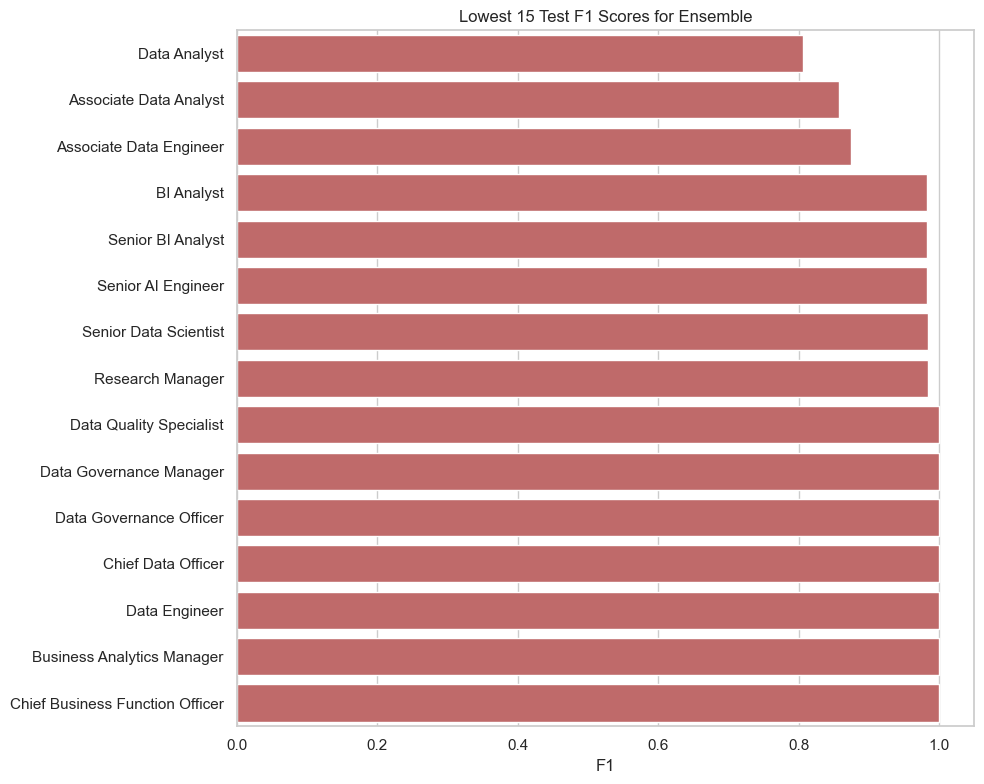

In [6]:
if per_class_metrics.empty:
    print("per_class_metrics.csv is empty or missing")
else:
    ensemble_test = per_class_metrics.query("split == 'test' and model == 'ensemble'").copy()
    lowest_f1 = ensemble_test.sort_values("f1").head(15)
    plt.figure(figsize=(10, 8))
    sns.barplot(data=lowest_f1, x="f1", y="className", color="indianred")
    plt.title("Lowest 15 Test F1 Scores for Ensemble")
    plt.xlabel("F1")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()

This chart shows the weakest ensemble classes on the test split by F1 score. Low-F1 classes are the ones the model finds hardest to separate cleanly, often because they overlap with adjacent roles or require more distinctive competency signals. This visualization helps you discuss model limitations honestly and identify which careers would benefit most from better data coverage, additional assessment questions, or refined competency definitions.


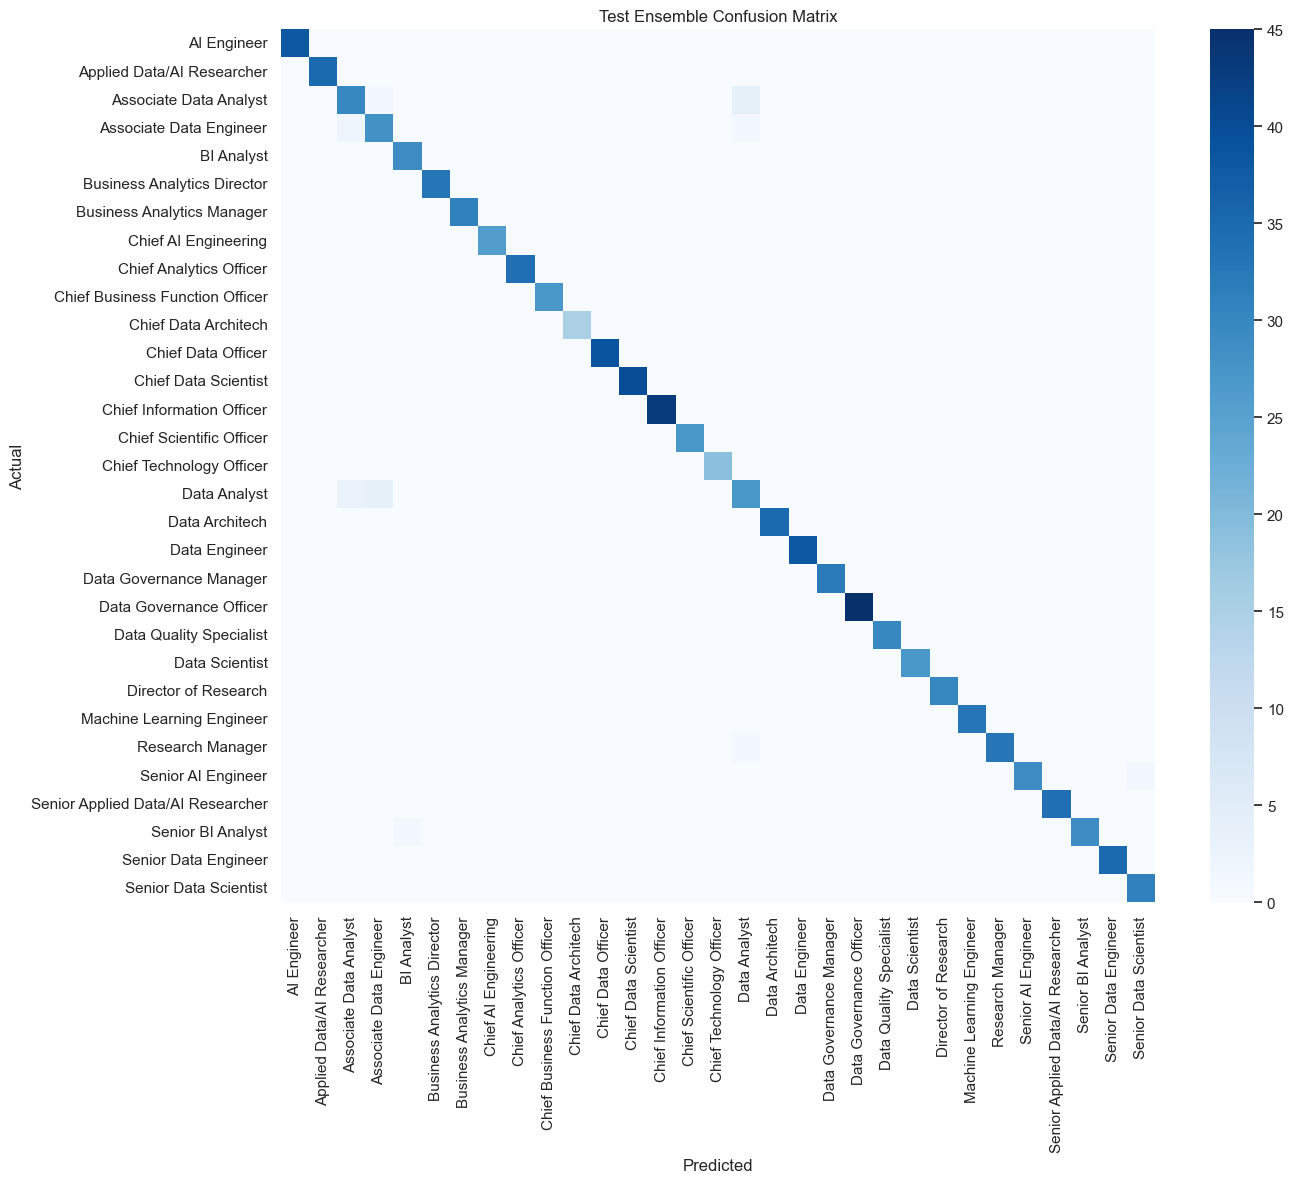

In [7]:
if confusion.empty:
    print("test_ensemble_confusion_matrix.csv is empty or missing")
else:
    cm = confusion.pivot(index="actualClass", columns="predictedClass", values="count").fillna(0)
    plt.figure(figsize=(14, 12))
    sns.heatmap(cm, cmap="Blues")
    plt.title("Test Ensemble Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

The confusion matrix shows where predictions land for every true class on the test split. Strong performance appears as darker values along the main diagonal, while off-diagonal concentrations highlight specific pairs of careers that the model tends to confuse. This is especially useful for explaining whether errors are random or whether they occur between structurally similar roles, which is usually a much more defensible kind of mistake for a career recommender.


## Synthetic Dataset Defense Visuals

These plots are meant to help explain why the synthetic dataset is useful for training:

- coverage across classes and levels
- variation around each profile base vector
- multiple archetypes per role
- harder validation subsets that stress-test the model
- learning-curve behavior as more synthetic samples are added


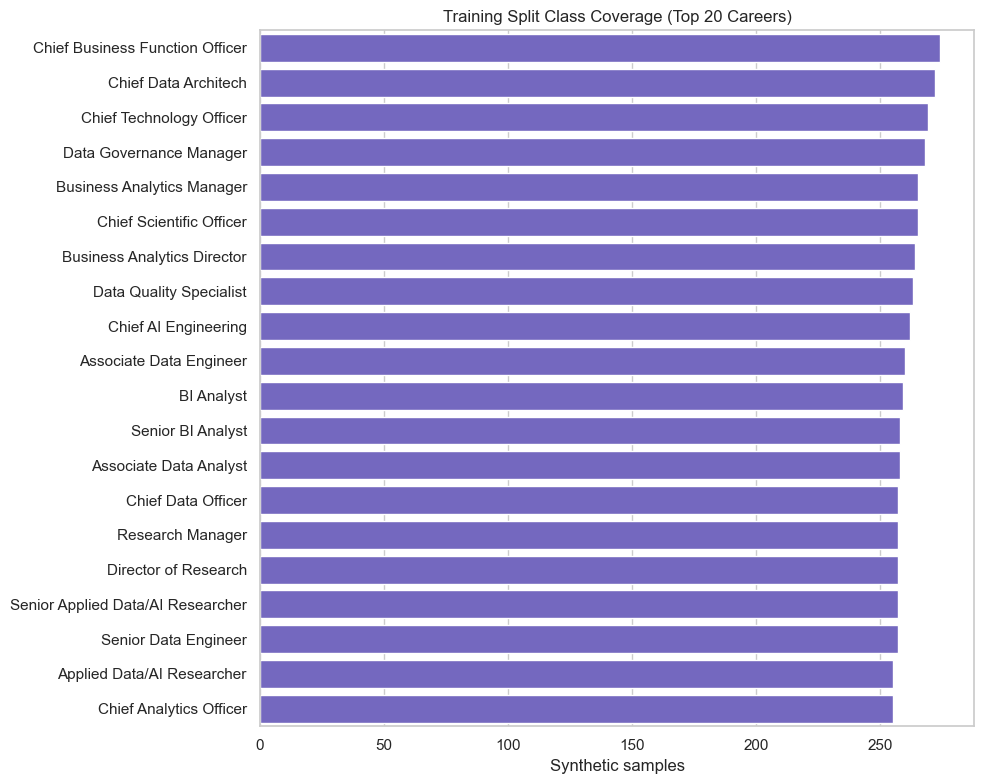

In [8]:
if training_class_dist.empty:
    print("training_split_class_distribution.csv is empty or missing")
else:
    train_only = training_class_dist.query("split == 'train'").sort_values("count", ascending=False).head(20)
    plt.figure(figsize=(10, 8))
    sns.barplot(data=train_only, x="count", y="careerName", color="slateblue")
    plt.title("Training Split Class Coverage (Top 20 Careers)")
    plt.xlabel("Synthetic samples")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()

This chart summarizes how many synthetic training rows were generated for the most represented careers. It helps show whether the synthetic dataset gives the model broad enough coverage across recommendation targets instead of concentrating too heavily on only a few roles. If coverage is reasonably distributed, that supports the claim that synthetic augmentation was used to improve trainability rather than simply inflate sample count.


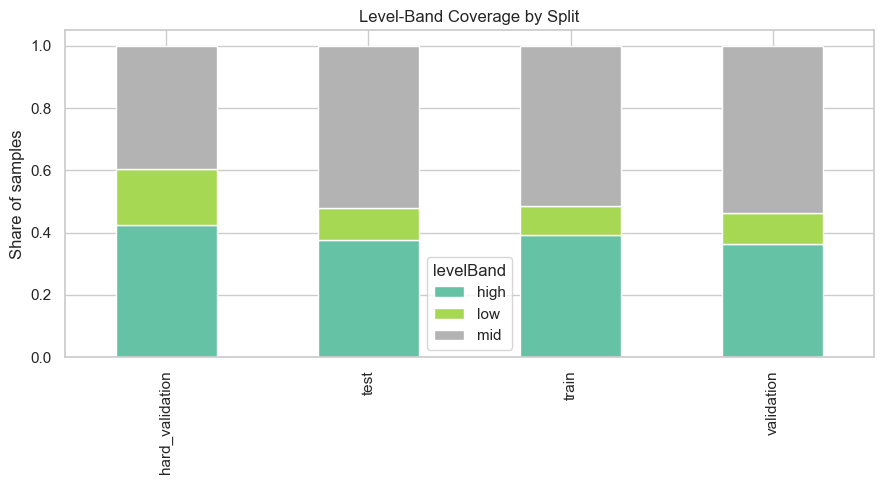

In [9]:
if training_level_dist.empty:
    print("training_split_level_distribution.csv is empty or missing")
else:
    level_pivot = training_level_dist.pivot(index="split", columns="levelBand", values="count").fillna(0)
    level_share = level_pivot.div(level_pivot.sum(axis=1), axis=0)
    level_share.plot(kind="bar", stacked=True, figsize=(9, 5), colormap="Set2")
    plt.title("Level-Band Coverage by Split")
    plt.ylabel("Share of samples")
    plt.xlabel("")
    plt.tight_layout()
    plt.show()

This level-band comparison shows how low-, mid-, and high-level profiles are distributed across the train, validation, and test splits. A healthier synthetic dataset should represent more than just entry-level or just advanced roles, because the recommender is meant to serve users across different career stages. Similar level coverage across splits also makes the later evaluation results easier to defend as fair and not split-biased.


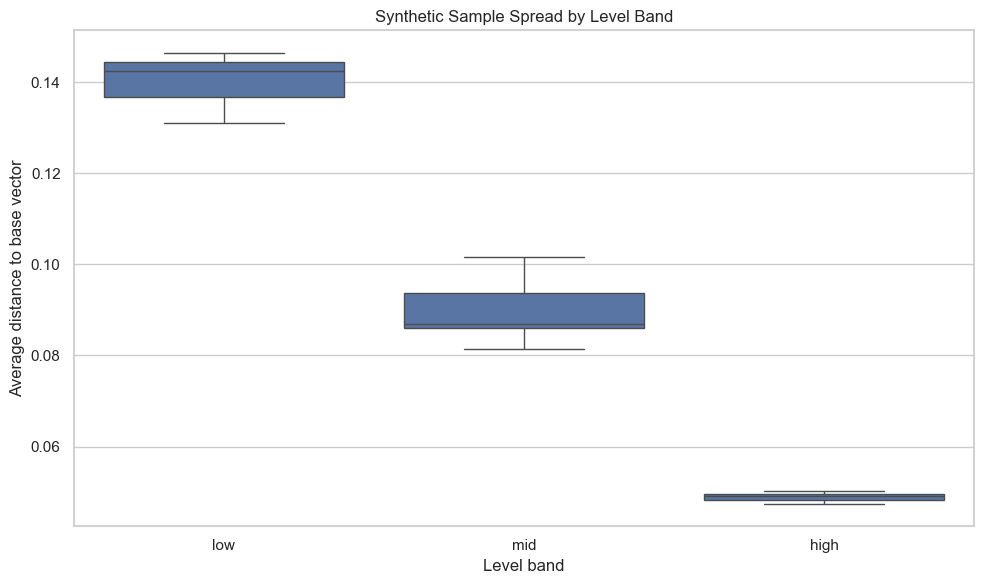

In [10]:
if training_profile_debug.empty:
    print("training_profile_debug.csv is empty or missing")
else:
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=training_profile_debug, x="levelBand", y="avgDistanceToBase", order=["low", "mid", "high"])
    plt.title("Synthetic Sample Spread by Level Band")
    plt.xlabel("Level band")
    plt.ylabel("Average distance to base vector")
    plt.tight_layout()
    plt.show()

The spread plot measures how far synthetic samples move away from each profile?s base competency template, grouped by level band. Very small spread can indicate near-duplicate synthetic rows, while very large spread can indicate unrealistic noise. A moderate spread is desirable because it suggests the generator is producing useful variation while still staying close to plausible skill patterns.


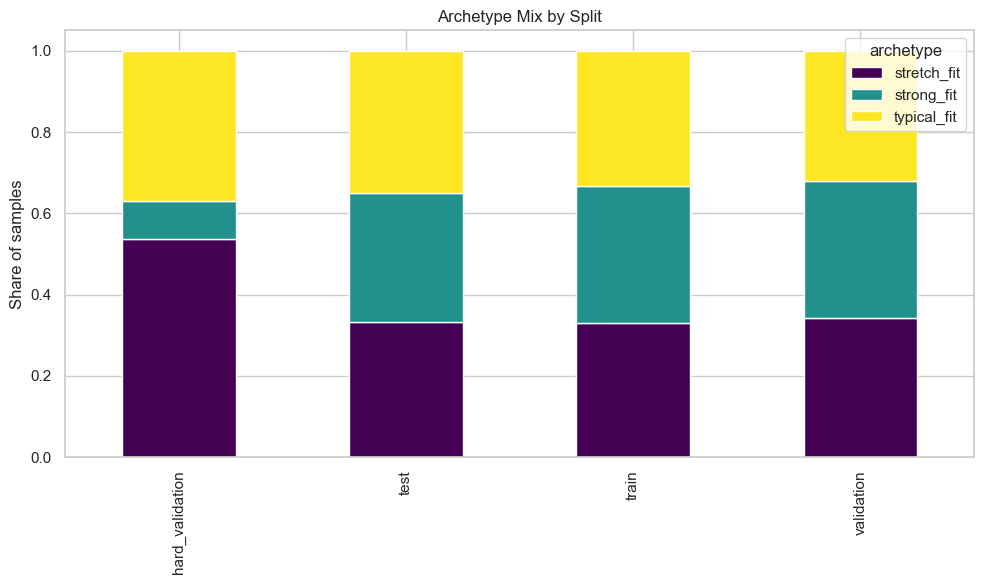

In [11]:
if training_archetype_dist.empty:
    print("training_split_archetype_distribution.csv is empty or missing")
else:
    archetype_pivot = training_archetype_dist.pivot(index="split", columns="archetype", values="count").fillna(0)
    archetype_share = archetype_pivot.div(archetype_pivot.sum(axis=1), axis=0)
    archetype_share.plot(kind="bar", stacked=True, figsize=(10, 6), colormap="viridis")
    plt.title("Archetype Mix by Split")
    plt.ylabel("Share of samples")
    plt.xlabel("")
    plt.tight_layout()
    plt.show()

This archetype distribution chart shows how strongly the synthetic dataset is composed of `strong_fit`, `typical_fit`, and `stretch_fit` examples across splits. Seeing all three archetypes represented helps support the idea that the training data reflects different readiness patterns rather than a single repeated profile style. It also helps explain why the recommender can handle both obvious and borderline candidate patterns.


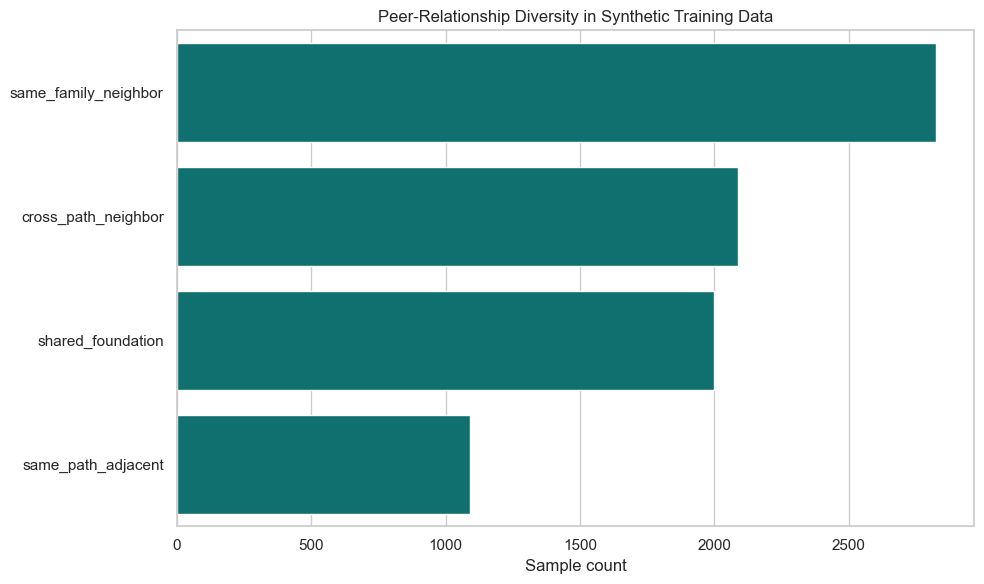

In [12]:
if training_relationship_dist.empty:
    print("training_split_relationship_distribution.csv is empty or missing")
else:
    rel = training_relationship_dist.query("split == 'train'").sort_values("count", ascending=False)
    plt.figure(figsize=(10, 6))
    sns.barplot(data=rel, x="count", y="peerRelationship", color="teal")
    plt.title("Peer-Relationship Diversity in Synthetic Training Data")
    plt.xlabel("Sample count")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()

This relationship plot shows how often synthetic profiles borrow structure from nearby or related careers. That matters because real users are often positioned between adjacent paths rather than matching one role perfectly. A meaningful mix here supports the argument that the synthetic generator preserves career-graph structure and gives the recommender exposure to transition-like profiles instead of only isolated labels.


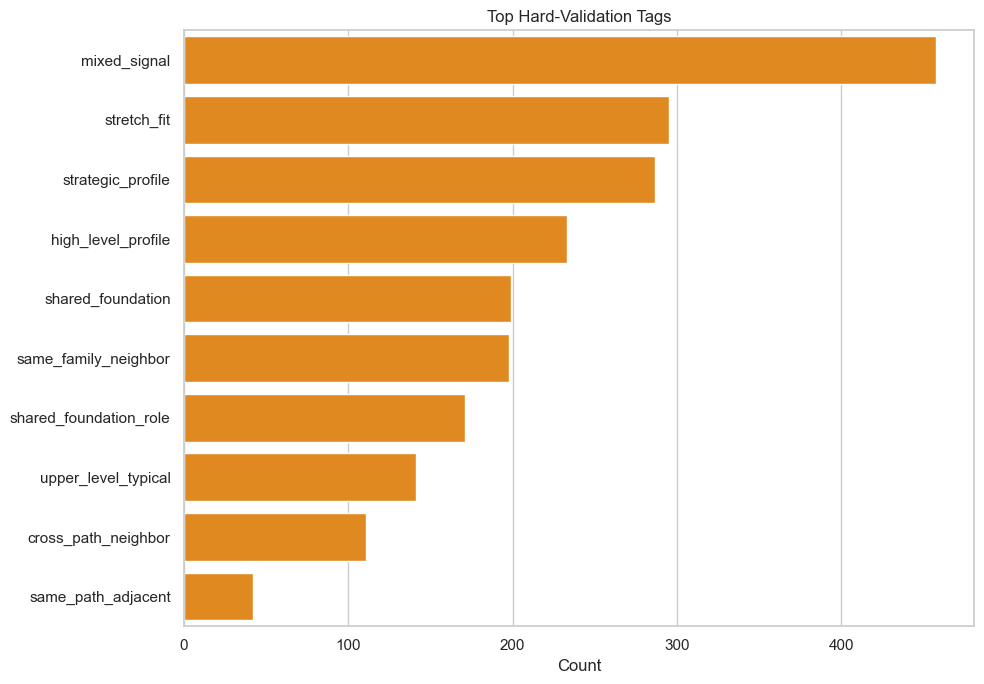

In [13]:
if training_hard_tags.empty:
    print("training_split_hard_tag_distribution.csv is empty or missing")
else:
    hard_only = training_hard_tags.query("split == 'hard_validation'").sort_values("count", ascending=False).head(15)
    plt.figure(figsize=(10, 7))
    sns.barplot(data=hard_only, x="count", y="tag", color="darkorange")
    plt.title("Top Hard-Validation Tags")
    plt.xlabel("Count")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()

These hard-validation tags summarize which difficult conditions appear most often in the tougher validation slice. Instead of treating all validation examples as equally easy, this visualization helps separate routine cases from intentionally ambiguous or stressful ones. That makes the later hard-validation metrics more interpretable and strengthens the robustness story around the evaluation process.


## Hyperparameter Tuning Visuals


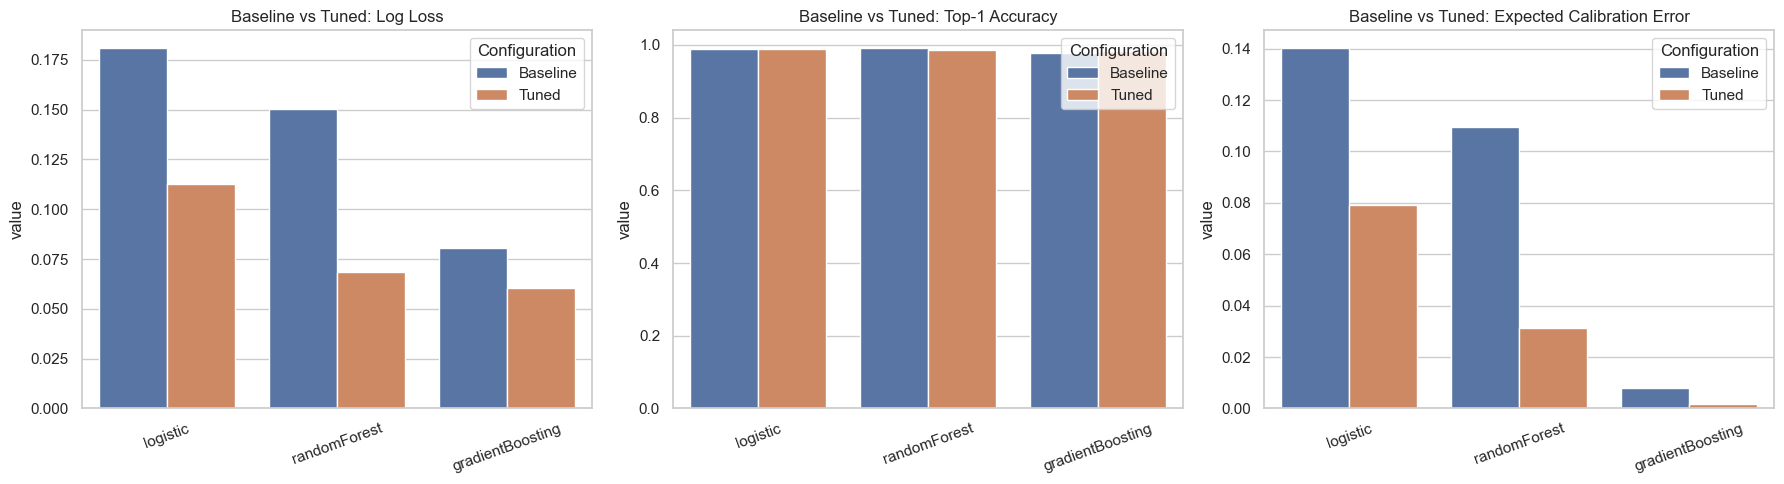

In [14]:
if hyperparameter_search_summary.empty:
    print("hyperparameter_search_summary.csv is empty or missing")
else:
    summary = hyperparameter_search_summary.query("model != 'ensemble'").copy()
    comparison_rows = []
    for _, row in summary.iterrows():
        for metric_key, metric_label in [
            ("log_loss", "Log Loss"),
            ("top1", "Top-1 Accuracy"),
            ("ece", "Expected Calibration Error"),
        ]:
            comparison_rows.append(
                {
                    "model": row["model"],
                    "stage": "Baseline",
                    "metric": metric_label,
                    "value": row.get(f"baseline_{metric_key}"),
                }
            )
            comparison_rows.append(
                {
                    "model": row["model"],
                    "stage": "Tuned",
                    "metric": metric_label,
                    "value": row.get(f"tuned_{metric_key}"),
                }
            )
    comparison = pd.DataFrame(comparison_rows).dropna(subset=["value"])
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for ax, metric_label in zip(axes, ["Log Loss", "Top-1 Accuracy", "Expected Calibration Error"]):
        panel = comparison.query("metric == @metric_label")
        sns.barplot(data=panel, x="model", y="value", hue="stage", ax=ax)
        ax.set_title(f"Baseline vs Tuned: {metric_label}")
        ax.set_xlabel("")
        ax.tick_params(axis="x", rotation=20)
        ax.legend_.set_title("Configuration")
    plt.tight_layout()
    plt.show()


These before-versus-tuned panels show whether hyperparameter search materially improved each base learner before ensembling. Lower `Log Loss` and `Expected Calibration Error` are better, while higher `Top-1 Accuracy` is better. If the tuned bars consistently move in the right direction, that supports the claim that tuning improved the individual models themselves rather than only shifting performance through the ensemble stage.


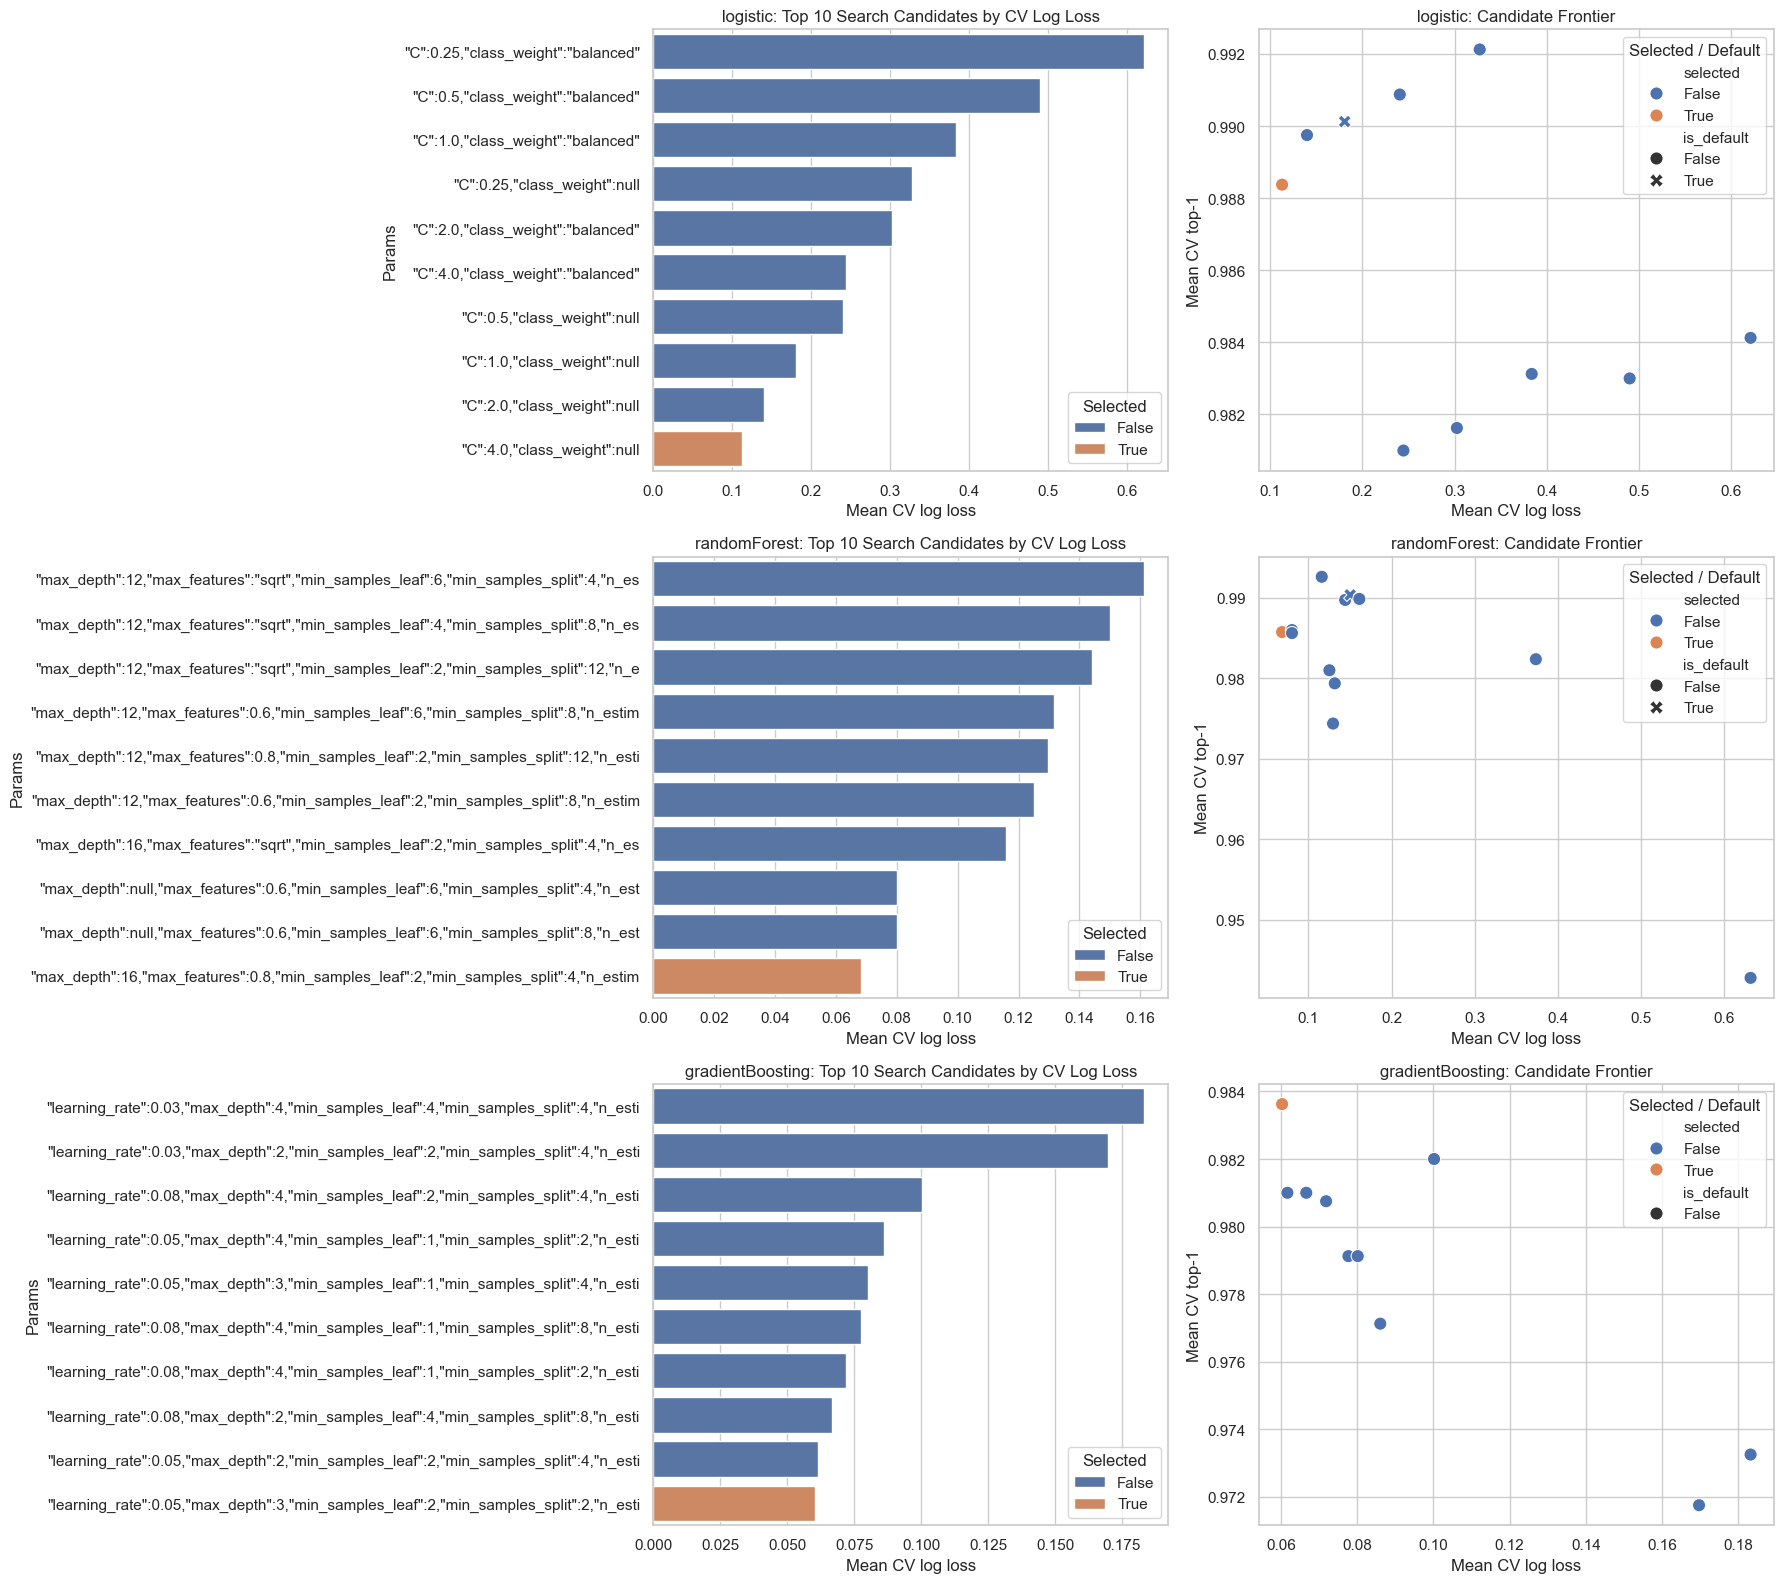

In [15]:
if hyperparameter_search_candidates.empty:
    print("hyperparameter_search_candidates.csv is empty or missing")
else:
    candidates = hyperparameter_search_candidates.dropna(subset=["mean_cv_log_loss", "mean_cv_top1"]).copy()
    candidates["param_label"] = candidates["params"].astype(str).str.replace('{', '', regex=False).str.replace('}', '', regex=False)
    candidates["param_label"] = candidates["param_label"].str.slice(0, 85)
    model_order = ["logistic", "randomForest", "gradientBoosting"]
    fig, axes = plt.subplots(len(model_order), 2, figsize=(18, 16))
    for row_index, model_name in enumerate(model_order):
        ranked = candidates.query("model == @model_name").sort_values("mean_cv_log_loss").head(10).copy()
        scatter = candidates.query("model == @model_name").copy()
        sns.barplot(data=ranked.sort_values("mean_cv_log_loss", ascending=False), x="mean_cv_log_loss", y="param_label", hue="selected", dodge=False, ax=axes[row_index, 0])
        axes[row_index, 0].set_title(f"{model_name}: Top 10 Search Candidates by CV Log Loss")
        axes[row_index, 0].set_xlabel("Mean CV log loss")
        axes[row_index, 0].set_ylabel("Params")
        axes[row_index, 0].legend(title="Selected")

        sns.scatterplot(data=scatter, x="mean_cv_log_loss", y="mean_cv_top1", hue="selected", style="is_default", s=90, ax=axes[row_index, 1])
        axes[row_index, 1].set_title(f"{model_name}: Candidate Frontier")
        axes[row_index, 1].set_xlabel("Mean CV log loss")
        axes[row_index, 1].set_ylabel("Mean CV top-1")
        axes[row_index, 1].legend(title="Selected / Default")
    plt.tight_layout()
    plt.show()


The candidate-ranking bars identify the strongest searched configurations for each model, while the scatter plots show the broader tradeoff frontier between `mean_cv_log_loss` and `mean_cv_top1`. The selected configuration should ideally sit in a strong region of that frontier rather than winning by accident. This pair of visuals helps justify both the winning hyperparameters and the overall quality of the search process.


C:\Users\jmvel\AppData\Local\Temp\ipykernel_39824\356223802.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=best_weights, x="model", y="weight", palette="crest", ax=axes[1])


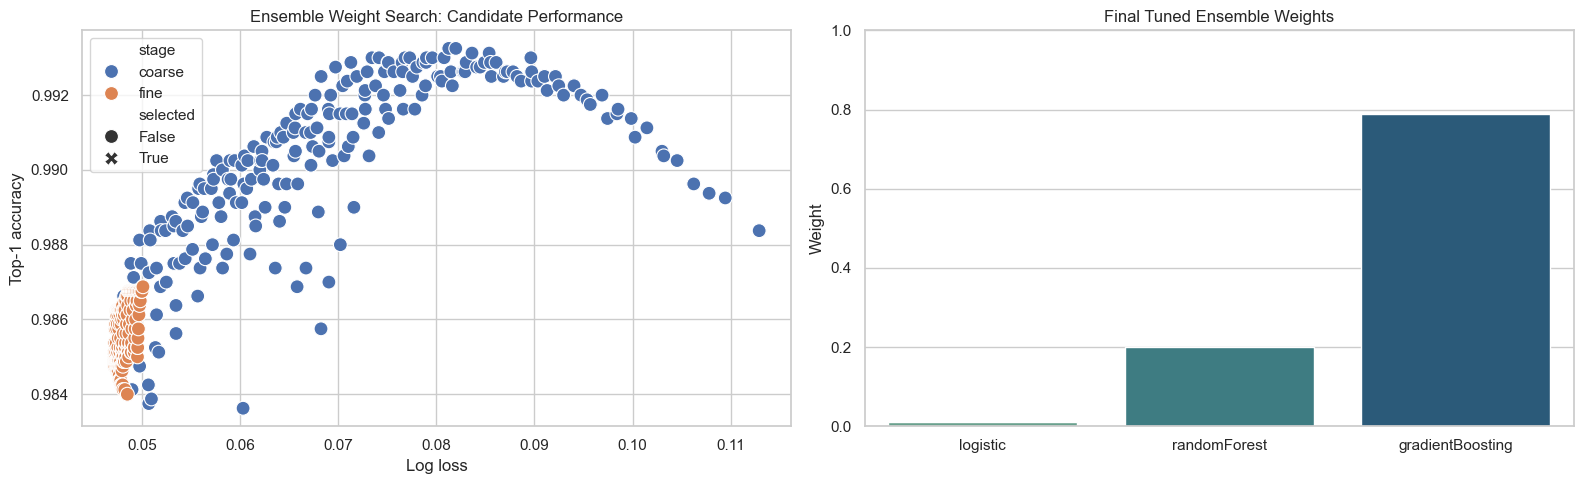

In [16]:
if ensemble_weight_search_trace.empty or ensemble_weight_search_summary.empty:
    print("ensemble_weight_search_trace.csv or ensemble_weight_search_summary.csv is empty or missing")
else:
    trace = ensemble_weight_search_trace.copy()
    summary = ensemble_weight_search_summary.iloc[0]
    selected = trace.query("selected == True").head(1)

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    sns.scatterplot(data=trace, x="log_loss", y="top1", hue="stage", style="selected", s=100, ax=axes[0])
    axes[0].set_title("Ensemble Weight Search: Candidate Performance")
    axes[0].set_xlabel("Log loss")
    axes[0].set_ylabel("Top-1 accuracy")

    best_weights = pd.DataFrame(
        {
            "model": ["logistic", "randomForest", "gradientBoosting"],
            "weight": [
                selected["logistic_weight"].iloc[0] if not selected.empty else 0.0,
                selected["random_forest_weight"].iloc[0] if not selected.empty else 0.0,
                selected["gradient_boosting_weight"].iloc[0] if not selected.empty else 0.0,
            ],
        }
    )
    sns.barplot(data=best_weights, x="model", y="weight", palette="crest", ax=axes[1])
    axes[1].set_title("Final Tuned Ensemble Weights")
    axes[1].set_ylim(0.0, 1.0)
    axes[1].set_xlabel("")
    axes[1].set_ylabel("Weight")
    plt.tight_layout()
    plt.show()


These ensemble-tuning visuals show how the coarse and fine search stages explored different weight combinations, and how the final blend allocates emphasis across the three base models. Because the selected point is highlighted directly in the search scatter, you can explain both where the best solution came from and what the final mixture looks like. This is useful when defending why the ensemble weights were tuned rather than fixed manually.


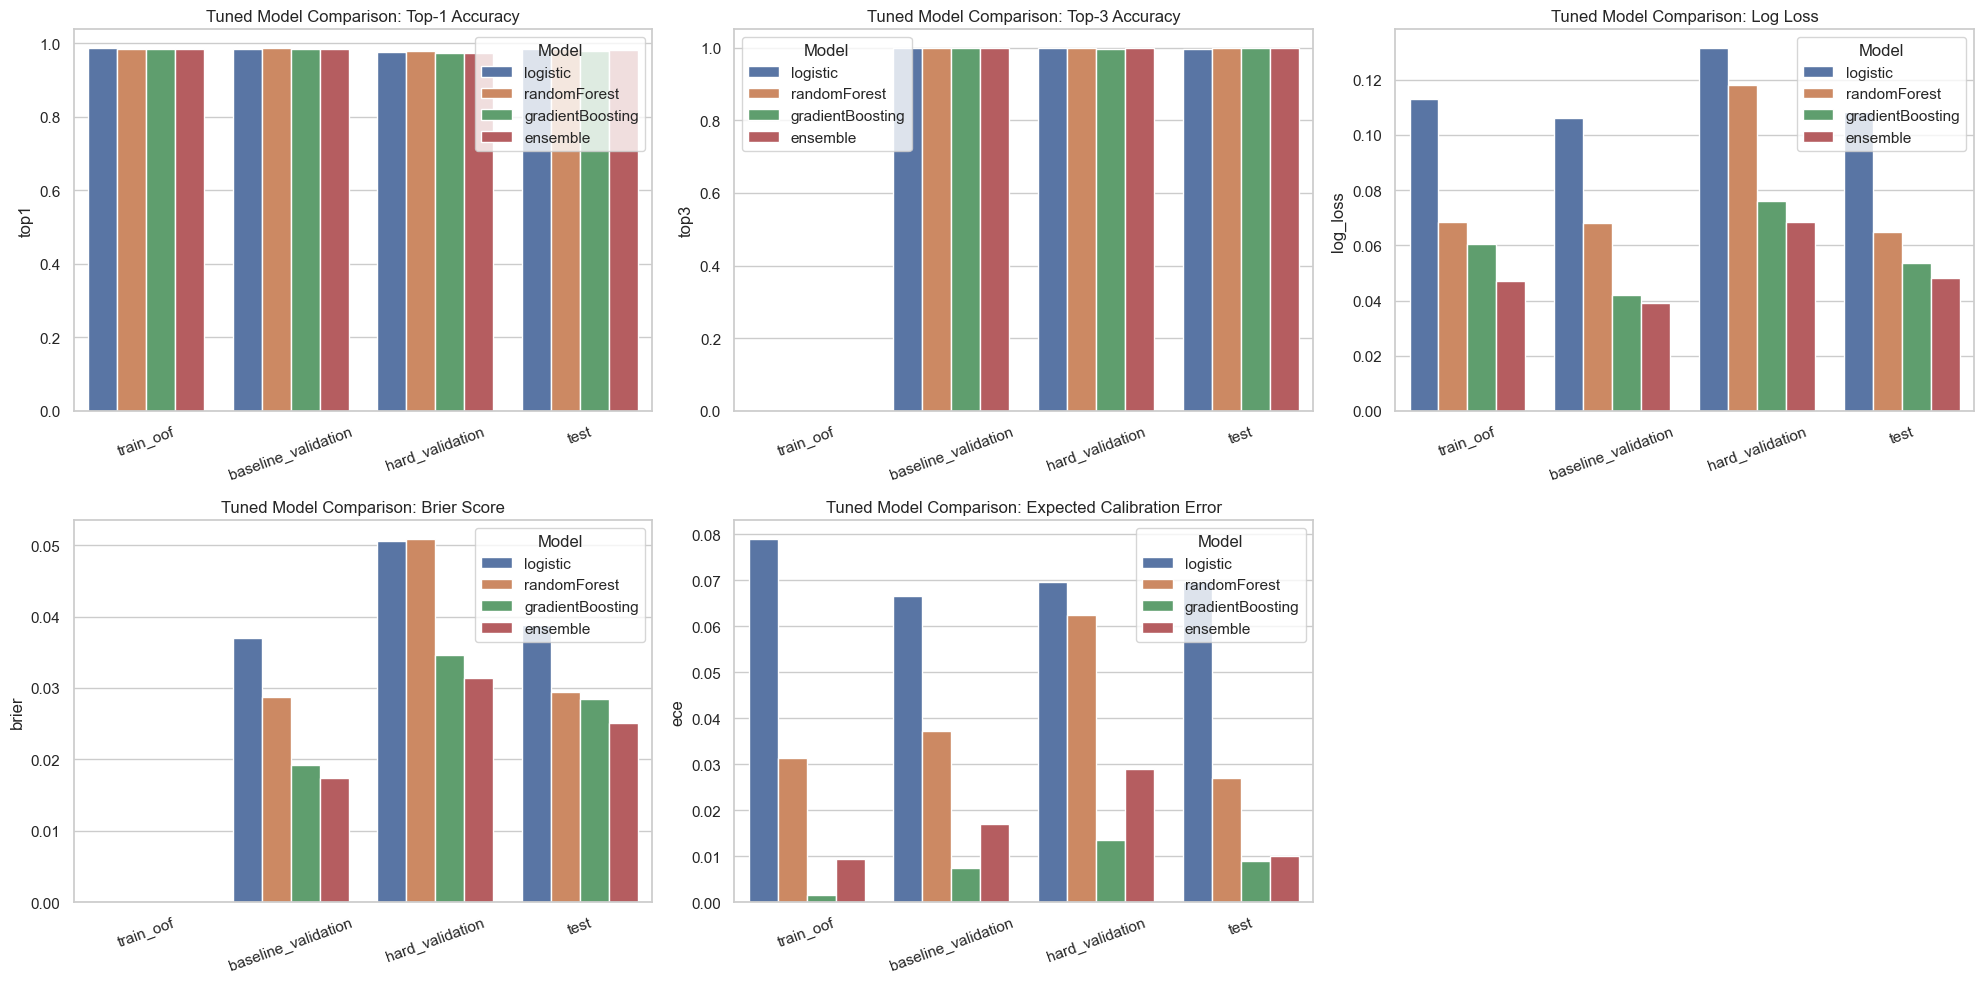

In [17]:
if model_comparison_tuning.empty or evaluation_metrics.empty:
    print("model_comparison_before_after_tuning.csv or evaluation_metrics.csv is empty or missing")
else:
    holdout = evaluation_metrics.copy()
    holdout = holdout[holdout["model"].isin(["logistic", "randomForest", "gradientBoosting", "ensemble"])].copy()
    holdout = holdout.rename(columns={"split": "stage", "logLoss": "log_loss"})

    oof_rows = []
    for _, row in model_comparison_tuning.iterrows():
        oof_rows.append({
            "model": row["model"],
            "stage": "train_oof",
            "top1": row.get("tuned_top1"),
            "top3": row.get("tuned_top3"),
            "log_loss": row.get("tuned_log_loss"),
            "brier": row.get("tuned_brier"),
            "ece": row.get("tuned_ece"),
        })
    oof_frame = pd.DataFrame(oof_rows)
    combined = pd.concat([
        holdout[["model", "stage", "top1", "top3", "log_loss", "brier", "ece"]],
        oof_frame,
    ], ignore_index=True)
    combined["stage"] = pd.Categorical(combined["stage"], categories=["train_oof", "baseline_validation", "hard_validation", "test"], ordered=True)

    fig, axes = plt.subplots(2, 3, figsize=(20, 10))
    axes = axes.flatten()
    metric_specs = [
        ("top1", "Top-1 Accuracy"),
        ("top3", "Top-3 Accuracy"),
        ("log_loss", "Log Loss"),
        ("brier", "Brier Score"),
        ("ece", "Expected Calibration Error"),
    ]

    for ax, (metric_key, title) in zip(axes, metric_specs):
        panel = combined.dropna(subset=[metric_key]).copy()
        sns.barplot(data=panel, x="stage", y=metric_key, hue="model", ax=ax)
        ax.set_title(f"Tuned Model Comparison: {title}")
        ax.set_xlabel("")
        ax.tick_params(axis="x", rotation=20)
        ax.legend_.set_title("Model")

    axes[-1].axis("off")
    plt.tight_layout()
    plt.show()


This final comparison panel places the tuned base models and tuned ensemble side by side across train-OOF, baseline validation, hard validation, and test. It helps answer two important questions: whether the ensemble is still the best final choice after all base models were tuned, and whether any gains seen during tuning hold up on the harder and fully held-out evaluation slices.


## Retraining Trace Visuals

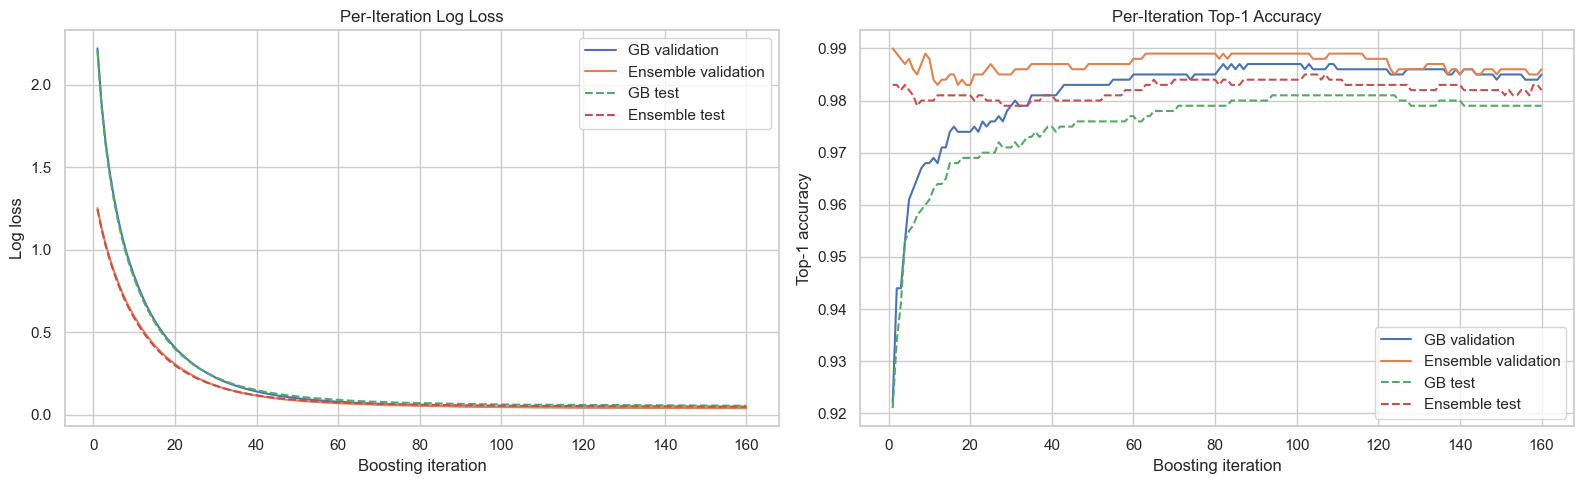

In [18]:
if gb_trace.empty:
    print("gradient_boosting_iteration_trace.csv is empty. Retrain the model with the updated pipeline, then rerun the export script.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    axes[0].plot(gb_trace["iteration"], gb_trace["gradient_boosting_validation_logLoss"], label="GB validation")
    axes[0].plot(gb_trace["iteration"], gb_trace["ensemble_validation_logLoss"], label="Ensemble validation")
    axes[0].plot(gb_trace["iteration"], gb_trace["gradient_boosting_test_logLoss"], label="GB test", linestyle="--")
    axes[0].plot(gb_trace["iteration"], gb_trace["ensemble_test_logLoss"], label="Ensemble test", linestyle="--")
    axes[0].set_title("Per-Iteration Log Loss")
    axes[0].set_xlabel("Boosting iteration")
    axes[0].set_ylabel("Log loss")
    axes[0].legend()

    axes[1].plot(gb_trace["iteration"], gb_trace["gradient_boosting_validation_top1"], label="GB validation")
    axes[1].plot(gb_trace["iteration"], gb_trace["ensemble_validation_top1"], label="Ensemble validation")
    axes[1].plot(gb_trace["iteration"], gb_trace["gradient_boosting_test_top1"], label="GB test", linestyle="--")
    axes[1].plot(gb_trace["iteration"], gb_trace["ensemble_test_top1"], label="Ensemble test", linestyle="--")
    axes[1].set_title("Per-Iteration Top-1 Accuracy")
    axes[1].set_xlabel("Boosting iteration")
    axes[1].set_ylabel("Top-1 accuracy")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

These retraining traces show how standalone gradient boosting and the final ensemble evolve as boosting iterations increase. In the left panel, lower log loss over time means the probability estimates are improving; in the right panel, higher top-1 means the ranking accuracy is improving. This visualization helps you discuss learning dynamics, stability, and whether later boosting rounds appear to help, plateau, or risk overfitting.


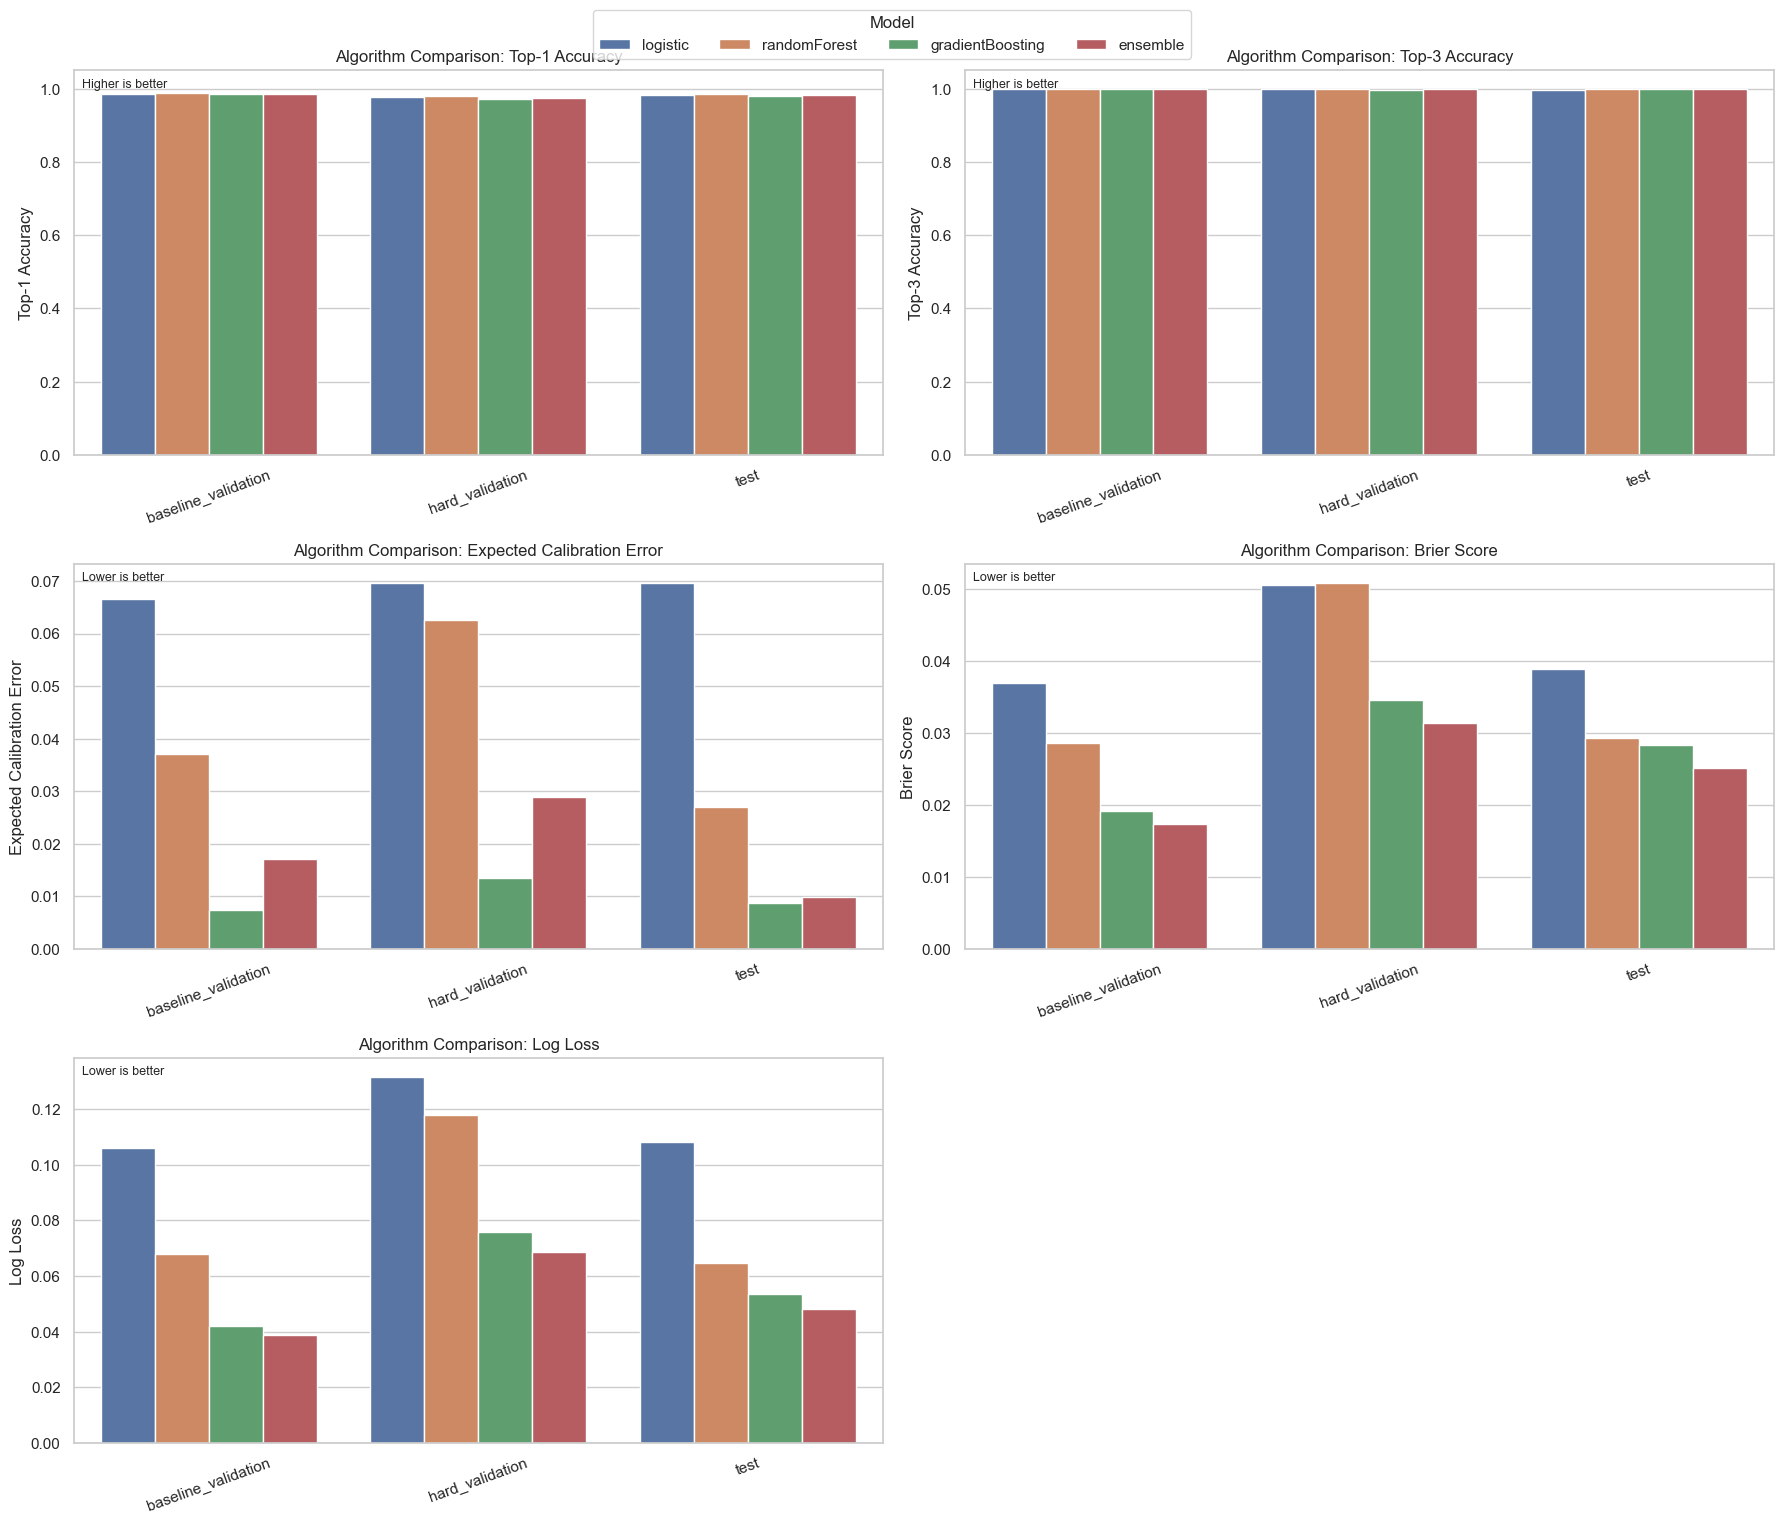

In [19]:
if evaluation_metrics.empty:
    print("evaluation_metrics.csv is empty or missing")
else:
    metric_specs = [
        ("top1", "Top-1 Accuracy", False),
        ("top3", "Top-3 Accuracy", False),
        ("ece", "Expected Calibration Error", True),
        ("brier", "Brier Score", True),
        ("logLoss", "Log Loss", True),
    ]
    split_order = ["baseline_validation", "hard_validation", "test"]
    model_order = ["logistic", "randomForest", "gradientBoosting", "ensemble"]
    metrics_frame = evaluation_metrics.copy()
    metrics_frame["split"] = pd.Categorical(metrics_frame["split"], categories=split_order, ordered=True)
    metrics_frame["model"] = pd.Categorical(metrics_frame["model"], categories=model_order, ordered=True)
    metrics_frame = metrics_frame.sort_values(["split", "model"])

    fig, axes = plt.subplots(3, 2, figsize=(18, 15))
    axes = axes.flatten()

    for ax, (metric, title, lower_is_better) in zip(axes, metric_specs):
        sns.barplot(data=metrics_frame, x="split", y=metric, hue="model", ax=ax)
        ax.set_title(f"Algorithm Comparison: {title}")
        ax.set_xlabel("")
        ax.tick_params(axis="x", rotation=20)
        ax.set_ylabel(title)
        if lower_is_better:
            ax.text(0.01, 0.98, "Lower is better", transform=ax.transAxes, ha="left", va="top", fontsize=9)
        else:
            ax.text(0.01, 0.98, "Higher is better", transform=ax.transAxes, ha="left", va="top", fontsize=9)
        if metric in {"top1", "top3"}:
            ax.set_ylim(0.0, 1.05)
        ax.legend_.set_title("Model")

    axes[-1].axis("off")
    handles, labels = axes[0].get_legend_handles_labels()
    for ax in axes[:5]:
        if ax.legend_ is not None:
            ax.legend_.remove()
    fig.legend(handles, labels, title="Model", loc="upper center", ncol=4, bbox_to_anchor=(0.5, 1.02))
    plt.tight_layout()
    plt.show()

These grouped comparison panels provide a compact cross-check of all four models across the main evaluation metrics and splits. They are especially useful when you need one figure that summarizes relative strengths in accuracy, ranking quality, and calibration at the same time. Because the split dimension is kept visible, the chart also helps reveal whether a model?s advantage is consistent or only appears in easier conditions.


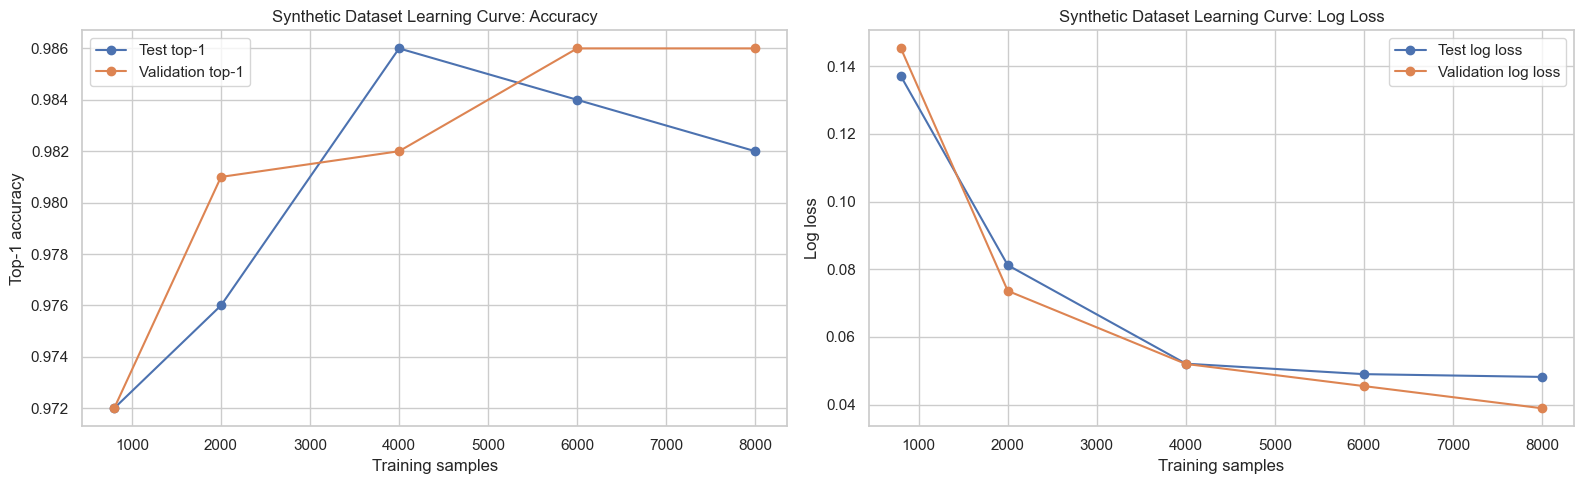

In [20]:
if learning_curve.empty:
    print("synthetic_learning_curve.csv is empty. Retrain the model with the updated pipeline, then rerun the export script.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    axes[0].plot(learning_curve["train_samples"], learning_curve["test_top1"], marker="o", label="Test top-1")
    axes[0].plot(learning_curve["train_samples"], learning_curve["validation_top1"], marker="o", label="Validation top-1")
    axes[0].set_title("Synthetic Dataset Learning Curve: Accuracy")
    axes[0].set_xlabel("Training samples")
    axes[0].set_ylabel("Top-1 accuracy")
    axes[0].legend()

    axes[1].plot(learning_curve["train_samples"], learning_curve["test_logLoss"], marker="o", label="Test log loss")
    axes[1].plot(learning_curve["train_samples"], learning_curve["validation_logLoss"], marker="o", label="Validation log loss")
    axes[1].set_title("Synthetic Dataset Learning Curve: Log Loss")
    axes[1].set_xlabel("Training samples")
    axes[1].set_ylabel("Log loss")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

This learning curve asks whether adding more synthetic training samples continues to improve recommendation quality. The accuracy panel shows whether more data raises predictive success, while the log-loss panel shows whether more data improves probability quality. If the curves improve and then flatten, that gives you a strong narrative about both the usefulness of synthetic augmentation and the point where additional synthetic rows begin to show diminishing returns.
